# CS 171 Homework 5

Begin this notebook by importing the pertinent packages for this assignment:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import torch
from torch import nn
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print("Using device:", device)

Using device: cuda


In [3]:
# import other packages here as necessary
from torch.utils.data import Dataset, DataLoader, TensorDataset
torch.manual_seed(39);

## Who can predict the local weather best?

In this homework assignment, we'll have a friendly competition to see who can make the best model for predicting future weather here in the Bay Area 

Provided with this assignment is a record of weather at the Hayward Airport. Let's read this data in and see what it looks like:

In [4]:
df = pd.read_csv('Hayward_Weather_Data.csv')
df.head()

,STATION,NAME,DATE,AWND,PRCP,TAVG,TMAX,TMIN
0,USW00093228,"HAYWARD AIR TERMINAL, CA US",1/1/00,8.05,0.00,49.0,54.0,44.0
1,USW00093228,"HAYWARD AIR TERMINAL, CA US",1/2/00,4.70,0.00,44.0,54.0,34.0
2,USW00093228,"HAYWARD AIR TERMINAL, CA US",1/3/00,3.80,0.00,47.0,55.0,39.0
3,USW00093228,"HAYWARD AIR TERMINAL, CA US",1/4/00,4.03,0.01,48.0,55.0,41.0
4,USW00093228,"HAYWARD AIR TERMINAL, CA US",1/5/00,4.70,0.00,52.0,61.0,42.0


As we can see, there are columns for the average wind speed; precipitation; and the average, maximum, and minimum temperature on a given day. Here, we will use the first three data columns.

Let see what these look like for the first year of data:

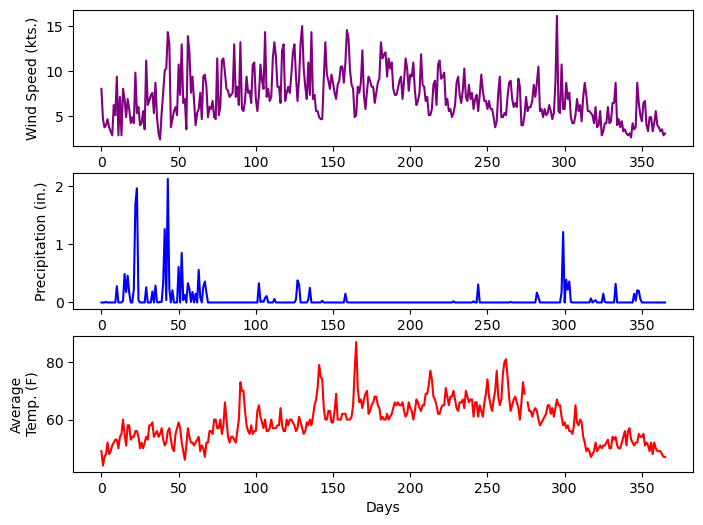

In [5]:
fig = plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(df['AWND'][:366], color='purple')
plt.ylabel('Wind Speed (kts.)')

plt.subplot(3,1,2)
plt.plot(df['PRCP'][:366], color='blue')
plt.ylabel('Precipitation (in.)')

plt.subplot(3,1,3)
plt.plot(df['TAVG'][:366], color='red')
plt.ylabel('Average\nTemp. (F)')
plt.xlabel('Days')

plt.show()

## Your Task
In the coding blocks below, your task is to create a Recurrent Neural Network that can predict the next 7 days of wind, precipitation, and temperature. Your model should take in a tensor with 30 days of data as shown in the example below.

For this competition, Mike will take everyone's trained models and make predictions. To score the predictions, he will compute the mean square errors of your model predictions and the real weather *one week after the homework assignment is due*. The best weather model will win a small prize. Note that you are graded on the steps in the creation of your model, not how well your model predicts that real weather.

#### Precautions
- This is a real dataset from the wild. This means that there will be missing data and bad values. Be sure to remove days without data or with bad values. Plotting the data will help to identify these periods.

In [6]:
# clean data
weather_df = df[['AWND', 'PRCP', 'TAVG']].copy()
weather_df = weather_df.dropna().reset_index(drop = True)
weather_df.head()

,AWND,PRCP,TAVG
0,8.05,0.00,49.0
1,4.70,0.00,44.0
2,3.80,0.00,47.0
3,4.03,0.01,48.0
4,4.70,0.00,52.0


In [7]:
# compute climatology & normalize data
features = weather_df[['AWND', 'PRCP', 'TAVG']].values

num_days = len(features)
num_years = num_days // 365
climatology = np.zeros((365, 3))

for year in range(num_years):
    year_slice = features[year * 365:(year + 1) * 365]
    climatology += year_slice

climatology /= num_years

features_clim = np.zeros_like(features)
features_anomaly = np.zeros_like(features)

for year in range(num_years):
    start = year * 365
    end = (year + 1) * 365
    features_clim[start:end] = climatology
    features_anomaly[start:end] = features[start:end] - climatology

if num_days % 365 != 0:
    leftover_start = num_years * 365
    leftover_length = num_days - leftover_start
    features_clim[leftover_start:] = climatology[:leftover_length]
    features_anomaly[leftover_start:] = features[leftover_start:] - climatology[:leftover_length]

mean_anomaly = features_anomaly.mean(axis=0)
std_anomaly = features_anomaly.std(axis=0)
features_anom_scaled = (features_anomaly - mean_anomaly) / std_anomaly

a_mean_wind, a_mean_precip, a_mean_temp = mean_anomaly
a_std_wind, a_std_precip, a_std_temp = std_anomaly

In [8]:
# preparing sequences
n_previous_days = 30
n_future_days = 7

X, y = [], []
for i in range(len(features_anom_scaled) - n_previous_days - n_future_days):
    X.append(features_anom_scaled[i:i + n_previous_days])
    y.append(features_anom_scaled[i + n_previous_days : i + n_previous_days + n_future_days])

X = np.stack(X)
y = np.stack(y)

print(np.shape(X), np.shape(y))

(6497, 30, 3) (6497, 7, 3)


In [9]:
# split into training and test sets
split_index = int(0.8 * len(X))

X_train, y_train = X[:split_index], y[:split_index]
X_test, y_test   = X[split_index:], y[split_index:]

X_train_tensor = torch.tensor(X_train).float()
X_test_tensor  = torch.tensor(X_test).float()
y_train_tensor = torch.tensor(y_train).float()
y_test_tensor  = torch.tensor(y_test).float()

batch_size = 16
train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_tensor,  y_test_tensor),  batch_size=batch_size, shuffle=False)

In [10]:
# lstm model
class WeatherRNN(nn.Module):
    def __init__(self, n_future_days, input_size=3, hidden_size=64, num_layers=1):
        super().__init__()
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, n_future_days * input_size)
        self.n_future_days = n_future_days
        self.input_size = input_size

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        out_fc = self.fc(last_hidden)
        return out_fc.view(-1, self.n_future_days, self.input_size)  

In [11]:
# training
n_future_days = 7
model = WeatherRNN(n_future_days=n_future_days)
model = model.to(device)

criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

EPOCHS = 20
train_losses, test_losses = [], []

for epoch in range(1, EPOCHS + 1):
    model.train()
    total_train_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_train_loss += loss.item() * xb.size(0)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    train_losses.append(avg_train_loss)

    # Evaluate on test data
    model.eval()
    total_test_loss = 0
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            preds = model(xb)
            loss = criterion(preds, yb)
            total_test_loss += loss.item() * xb.size(0)

    avg_test_loss = total_test_loss / len(test_loader.dataset)
    test_losses.append(avg_test_loss)

    print(f"Epoch {epoch}: Train MSE: {avg_train_loss:.4f},  Test MSE: {avg_test_loss:.4f}")

Epoch 1: Train MSE: 0.7410,  Test MSE: 0.9616
Epoch 2: Train MSE: 0.6969,  Test MSE: 0.9531
Epoch 3: Train MSE: 0.6875,  Test MSE: 0.9470
Epoch 4: Train MSE: 0.6824,  Test MSE: 0.9430
Epoch 5: Train MSE: 0.6773,  Test MSE: 0.9419
Epoch 6: Train MSE: 0.6738,  Test MSE: 0.9398
Epoch 7: Train MSE: 0.6694,  Test MSE: 0.9447
Epoch 8: Train MSE: 0.6641,  Test MSE: 0.9559
Epoch 9: Train MSE: 0.6591,  Test MSE: 0.9576
Epoch 10: Train MSE: 0.6508,  Test MSE: 0.9713
Epoch 11: Train MSE: 0.6448,  Test MSE: 0.9639
Epoch 12: Train MSE: 0.6325,  Test MSE: 0.9793
Epoch 13: Train MSE: 0.6261,  Test MSE: 1.0142
Epoch 14: Train MSE: 0.6194,  Test MSE: 0.9992
Epoch 15: Train MSE: 0.6028,  Test MSE: 1.0020
Epoch 16: Train MSE: 0.5917,  Test MSE: 1.0226
Epoch 17: Train MSE: 0.5854,  Test MSE: 1.0391
Epoch 18: Train MSE: 0.5729,  Test MSE: 1.0199
Epoch 19: Train MSE: 0.5623,  Test MSE: 1.0519
Epoch 20: Train MSE: 0.5512,  Test MSE: 1.0427


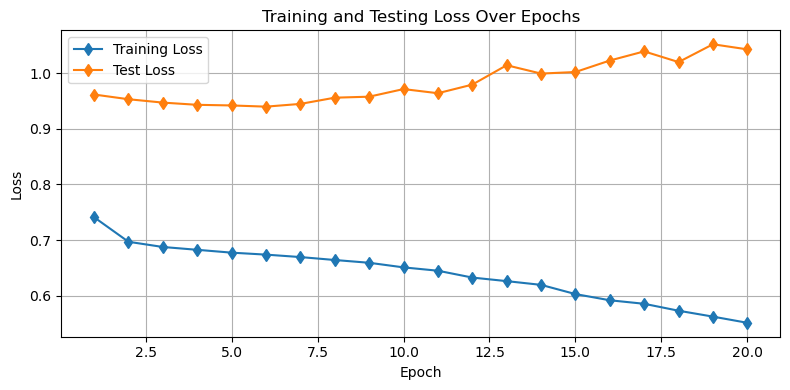

In [12]:
# graph results
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS + 1), train_losses, 'd-', label='Training Loss')
plt.plot(range(1, EPOCHS + 1), test_losses, 'd-', label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Testing Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Saving Your Model
When you are done with your model, save a copy so that Mike can run your model. You can save a model by storing the architecture of the class in a `.py` file and then storing the weights of your model with PyTorch as a pickle file:

In [13]:
# first, save your model class as a .py file
# e.g. WeatherRNN.py
model_code = '''
import torch
from torch import nn

class WeatherRNN(nn.Module):
    def __init__(self, n_future_days, input_size=3, hidden_size=64, num_layers=1):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True
        )
        self.fc = nn.Linear(hidden_size, n_future_days * input_size)
        self.n_future_days = n_future_days
        self.input_size = input_size

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        out_fc = self.fc(last_hidden)
        return out_fc.view(-1, self.n_future_days, self.input_size)
'''

with open('WeatherRNN.py', 'w') as f:
    f.write(model_code)

In [14]:
# then, save the parameters of your model with the following
# torch.save(my_model.state_dict(), 'WeatherRNN')
weights_path = 'WeatherRNN.pt'
torch.save(model.state_dict(), weights_path)

## Instructions for Running Your Model
To test your model, Mike is going to need to know how to use it! Here is an example dataset, model and set of instructions to see how this section should operate. You should update this section depending on the creation of your model:

In [15]:
# read in the test data
# this data will be replaced with real data
# one week after the assignment due data
test_data = np.float32(np.fromfile('Test_Weather_Data', '>f4').reshape((1, 30, 3)))

from WeatherRNN import WeatherRNN
loaded_model = WeatherRNN(7, 3).to(device)
state_dict = torch.load('WeatherRNN.pt', map_location=device)
loaded_model.load_state_dict(state_dict)
loaded_model.eval()

C:\Users\Laser\AppData\Local\Temp\ipykernel_97756\264001082.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('WeatherRNN.pt', map_location=device)

WeatherRNN(
  (lstm): LSTM(3, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=21, bias=True)
)

#### Example Instructions
To use my model, first normalize the data with the following parameters:

In [16]:
mean_wind_anom   = a_mean_wind
std_wind_anom    = a_std_wind
mean_precip_anom = a_mean_precip
std_precip_anom  = a_std_precip
mean_temp_anom   = a_mean_temp
std_temp_anom    = a_std_temp

In [17]:
# normalize
anomaly_input = test_data.copy()
for i in range(30):
    day_index = i % 365
    anomaly_input[:, i, :] -= climatology[day_index]

anomaly_input[:, :, 0] -= mean_wind_anom
anomaly_input[:, :, 0] /= std_wind_anom
anomaly_input[:, :, 1] -= mean_precip_anom
anomaly_input[:, :, 1] /= std_precip_anom
anomaly_input[:, :, 2] -= mean_temp_anom
anomaly_input[:, :, 2] /= std_temp_anom

In [18]:
input_tensor = torch.tensor(anomaly_input).float().to(device)

In [23]:
with torch.no_grad(): forecast_scaled = loaded_model(input_tensor).cpu().numpy()
forecast = forecast_scaled.copy()

with open("rajaie_ryan_forecast.txt", "w") as f:
    for row in forecast[0]:  
        f.write(",".join(map(str, row)) + "\n")

To make a forecast of absolute values, de-normalize the data:

In [20]:
for i in range(7):
    day_index = (30 + i) % 365
    forecast[:, i, 0] = forecast[:, i, 0] * std_wind_anom + mean_wind_anom
    forecast[:, i, 1] = forecast[:, i, 1] * std_precip_anom + mean_precip_anom
    forecast[:, i, 2] = forecast[:, i, 2] * std_temp_anom + mean_temp_anom
    forecast[:, i, :] += climatology[day_index]
    forecast[:, i, :] += climatology[day_index]

Then, plot everything to visualize the forecast:

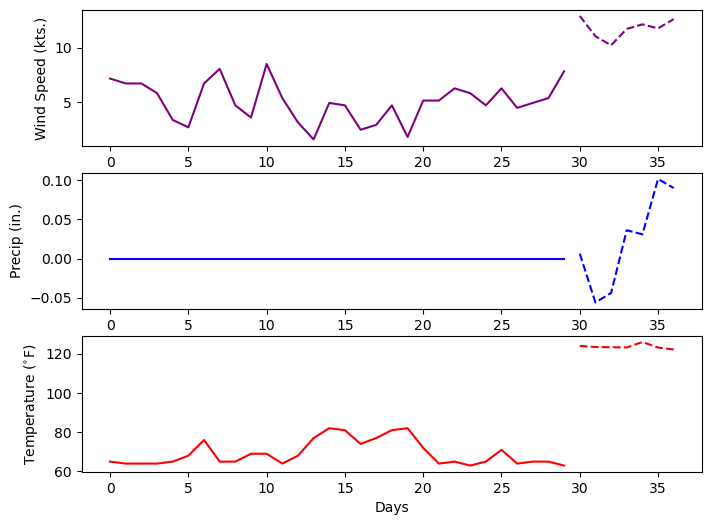

In [21]:
fig = plt.figure(figsize=(8,6))

plt.subplot(3,1,1)
plt.plot(test_data[0,:,0], color='purple')
plt.plot(np.arange(30,37), forecast[0,:,0], '--', color='purple')
plt.ylabel('Wind Speed (kts.)')

plt.subplot(3,1,2)
plt.plot(test_data[0,:,1], color='blue')
plt.plot(np.arange(30,37), forecast[0,:,1], '--', color='blue')
plt.ylabel('Precip (in.)')

plt.subplot(3,1,3)
plt.plot(test_data[0,:,2], color='red')
plt.plot(np.arange(30,37), forecast[0,:,2], '--', color='red')
plt.ylabel('Temperature ($^{\\circ}$F)')
plt.xlabel('Days')
plt.show()